# Seq2Seq Model 1 — T5 Efficient Tiny with LoRA

This notebook presents the fine-tuning of the `google/t5-efficient-tiny` sequence-to-sequence model using LoRA.

The model is trained on the same instruction-response dataset used in the causal language model experiments. The objective is to evaluate how an encoder-decoder architecture performs on the washing machine manual domain.

The same train/test split and test instruction are reused to ensure a fair comparison across models.

## 1. Import Libraries

In [23]:
import json
from pathlib import Path

import torch
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    TrainingArguments,
    Trainer,
    DataCollatorForSeq2Seq
)

from peft import (
    LoraConfig,
    TaskType,
    get_peft_model,
    PeftModel
)

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Torch version: 2.12.0+cpu
CUDA available: False


## 2. Loading the Dataset

The previously saved train and test splits are loaded from disk. Reusing the same split across all models ensures a fair comparison between causal and sequence-to-sequence architectures.

In [24]:
dataset = load_dataset(
    "json",
    data_files={
        "train": "../data/splits/train.jsonl",
        "test": "../data/splits/test.jsonl"
    }
)

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['instruction', 'response', 'text'],
        num_rows: 99
    })
    test: Dataset({
        features: ['instruction', 'response', 'text'],
        num_rows: 25
    })
})


## 3. Loading the Base Model

The first sequence-to-sequence model is `google/t5-efficient-tiny`. This model was selected because it is lightweight and suitable for CPU-based fine-tuning.

In [25]:
model_name = "google/flan-t5-small"

tokenizer = AutoTokenizer.from_pretrained(model_name)

base_model = AutoModelForSeq2SeqLM.from_pretrained(
    model_name
)

print(f"Model loaded: {model_name}")
print(type(base_model))

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Model loaded: google/flan-t5-small
<class 'transformers.models.t5.modeling_t5.T5ForConditionalGeneration'>


## 4. Inference Before Fine-Tuning

Before applying LoRA, the base sequence-to-sequence model is evaluated using the same test instruction used in the causal model experiments.

In [26]:
def generate_seq2seq_response(model, tokenizer, instruction):
    inputs = tokenizer(
        instruction,
        return_tensors="pt",
        truncation=True,
        max_length=128
    )

    outputs = model.generate(
        **inputs,
        max_new_tokens=30,
        num_beams=4,
        do_sample=False,
        repetition_penalty=1.5,
        no_repeat_ngram_size=2
    )

    return tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    ).strip()

In [27]:
test_instruction = (
    "How do you unlock the door during a wash cycle?"
)

expected_response = (
    "Press START/PAUSE for 3 seconds."
)

print("=== BEFORE FINE-TUNING ===")
print(f"Instruction: {test_instruction}")
print(f"Expected response: {expected_response}")

print(
    "Base response:",
    generate_seq2seq_response(
        base_model,
        tokenizer,
        test_instruction
    )
)

=== BEFORE FINE-TUNING ===
Instruction: How do you unlock the door during a wash cycle?
Expected response: Press START/PAUSE for 3 seconds.
Base response: Use a screwdriver to unlock the door.


## 5. Tokenization

For sequence-to-sequence training, the instruction is used as the input text and the response is used as the target text. This differs from causal language modeling, where instruction and response are combined into a single sequence.

In [28]:
def tokenize_seq2seq_function(examples):
    inputs = examples["instruction"]
    targets = examples["response"]

    model_inputs = tokenizer(
        inputs,
        padding="max_length",
        truncation=True,
        max_length=128
    )

    labels = tokenizer(
        targets,
        padding="max_length",
        truncation=True,
        max_length=64
    )

    labels_ids = labels["input_ids"]

    labels_ids = [
        [
            token if token != tokenizer.pad_token_id else -100
            for token in sequence
        ]
        for sequence in labels_ids
    ]

    model_inputs["labels"] = labels_ids

    return model_inputs

In [29]:
tokenized_datasets = dataset.map(
    tokenize_seq2seq_function,
    batched=True,
    remove_columns=[
        "instruction",
        "response",
        "text"
    ]
)

print("Tokenized dataset:")
print(tokenized_datasets)

Map:   0%|          | 0/99 [00:00<?, ? examples/s]

Map:   0%|          | 0/25 [00:00<?, ? examples/s]

Tokenized dataset:
DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 99
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 25
    })
})


## 6. LoRA Configuration

LoRA is applied to the attention projection layers of the T5 model. For encoder-decoder models, adapting the query and value projections is a common strategy because these layers directly affect how the model attends to the input and generates the output.

In [30]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q", "v"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.SEQ_2_SEQ_LM,
    inference_mode=False
)

In [31]:
lora_model = get_peft_model(
    base_model,
    lora_config
)

lora_model.print_trainable_parameters()
print(type(lora_model))

trainable params: 688,128 || all params: 77,649,280 || trainable%: 0.8862
<class 'peft.peft_model.PeftModelForSeq2SeqLM'>


## 7. Data Collator

The data collator prepares batches for sequence-to-sequence training. It handles padding and organizes the input and target sequences for the encoder-decoder model.

In [32]:
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=lora_model
)

## 8. Training Configuration

The training configuration was adjusted for a CPU-only environment. A small batch size, short sequence lengths, and three epochs are used to keep training feasible while still allowing LoRA-based adaptation.

In [33]:
models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

training_args = TrainingArguments(
    output_dir="../models/results_flan_t5_small",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-4,

    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,

    num_train_epochs=3,

    weight_decay=0.01,

    logging_steps=10,

    load_best_model_at_end=True,
    report_to="none",

    save_total_limit=1,
    dataloader_pin_memory=False
)

## 9. Trainer Initialization

The Hugging Face Trainer is initialized with the LoRA-adapted sequence-to-sequence model, training arguments, tokenized datasets, and data collator.

In [34]:
trainer = Trainer(
    model=lora_model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    data_collator=data_collator,
)

print(type(trainer.model))

<class 'peft.peft_model.PeftModelForSeq2SeqLM'>


## 10. Model Training

The model is trained using LoRA adapters while the original base model parameters remain frozen.

In [35]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,3.822560,3.386366
2,3.511893,3.338431
3,3.716891,3.328808


TrainOutput(global_step=150, training_loss=3.5914153798421222, metrics={'train_runtime': 135.5278, 'train_samples_per_second': 2.191, 'train_steps_per_second': 1.107, 'total_flos': 13959329218560.0, 'train_loss': 3.5914153798421222, 'epoch': 3.0})

In [36]:
eval_results = trainer.evaluate()

print("Evaluation results:")
print(eval_results)

Training Loss,Validation Loss,Epoch
3.716891,3.328808,3


Evaluation results:
{'eval_loss': 3.328808307647705}


## 11. Saving the Fine-Tuned Model

The LoRA adapter weights and tokenizer are saved locally in the `../models/` directory. This path follows the project structure required for later API integration.

In [37]:
seq2seq_model_1_path = "../models/lora_seq2seq_model_1"

lora_model.save_pretrained(seq2seq_model_1_path)
tokenizer.save_pretrained(seq2seq_model_1_path)

print(f"Model and tokenizer saved to: {seq2seq_model_1_path}")

Model and tokenizer saved to: ../models/lora_seq2seq_model_1


## 12. Inference After Fine-Tuning

After training, the fine-tuned sequence-to-sequence model is evaluated using the same instruction used before fine-tuning. The generated response is compared with the expected answer to analyze the effect of LoRA adaptation.

In [38]:
# Load the fine-tuned LoRA adapters

model_path = "../models/lora_seq2seq_model_1"

finetuned_base_model = AutoModelForSeq2SeqLM.from_pretrained(
    model_name
)

finetuned_model = PeftModel.from_pretrained(
    finetuned_base_model,
    model_path
)

finetuned_tokenizer = AutoTokenizer.from_pretrained(
    model_path
)

print("=== AFTER FINE-TUNING ===")
print(f"Instruction: {test_instruction}")

print(
    "Fine-tuned response:",
    generate_seq2seq_response(
        finetuned_model,
        finetuned_tokenizer,
        test_instruction
    )
)

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


=== AFTER FINE-TUNING ===
Instruction: How do you unlock the door during a wash cycle?
Fine-tuned response: Unlock the door.


In [39]:
sample = dataset["train"][0]

print(sample["instruction"])
print(sample["response"])

What causes delay in filling during washing cycle?
Clogged water inlet filters can delay filling.


In [40]:
generate_seq2seq_response(
    lora_model,
    tokenizer,
    sample["instruction"]
)

'Filling can be delayed by a delay in filling during washing cycle.'

## 13. Loss Graphs

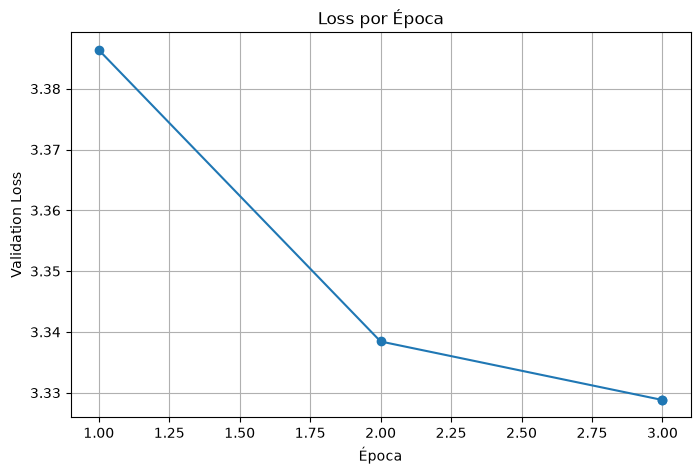

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

logs = pd.DataFrame(trainer.state.log_history)

# Apenas avaliações por época
eval_logs = logs[logs["eval_loss"].notna()]

plt.figure(figsize=(8,5))
plt.plot(
    eval_logs["epoch"],
    eval_logs["eval_loss"],
    marker="o"
)

plt.title("Loss por Época")
plt.xlabel("Época")
plt.ylabel("Validation Loss")
plt.grid(True)

plt.show()

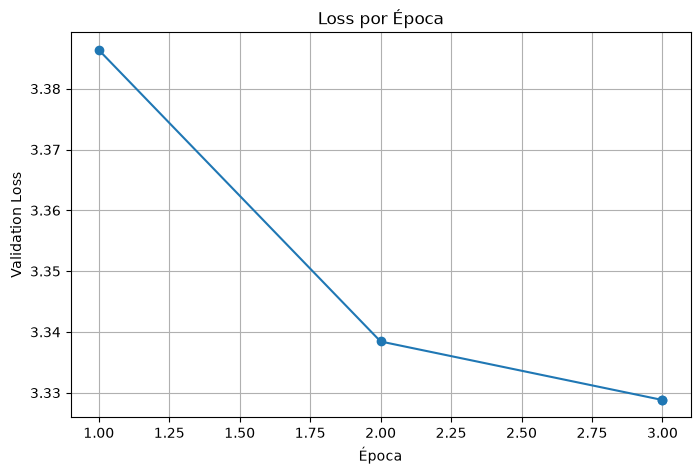

In [42]:
plt.figure(figsize=(8,5))

plt.plot(
    eval_logs["epoch"],
    eval_logs["eval_loss"],
    marker="o"
)

plt.title("Loss por Época")
plt.xlabel("Época")
plt.ylabel("Validation Loss")
plt.grid(True)

plt.savefig(
    "../reports/loss_flan_t5_small.png",
    bbox_inches="tight"
)

plt.show()